# Beta-VAE arch x beta sweep (exploration + diagnostics)

Joint sweep over `(base_channels, depth, beta)` at fixed `latent_dim=16`
(Stage 1, 60 configs), then an optional `(lr, weight_decay)` sweep at a
user-chosen Stage-1 config (Stage 2, 9 configs). **No automatic winner
selection and no checkpoint persistence**: this notebook produces
diagnostics; you pick the architecture and copy its config into
`06_vae_sweep_winner.ipynb`.

Sweep figures: Bousquet Fig 3 / Fig 5 replicas, a base x depth recon
overview, and a per-dim KL collapse heatmap across all 60 configs to
spot dim-level posterior collapse at a glance.


In [1]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

# Anchor to the repo root so paleoreco imports and relative file paths
# resolve regardless of where Jupyter was launched from.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from paleoreco.data import (
    PaleoFieldDataset,
    apply_zscore,
    build_prior_cube,
    compute_zscore_stats,
)
from paleoreco.splits import block_stride_split, summarize_split
from paleoreco.models.autoencoder import (
    ConvAE,
    ConvBetaVAE,
    count_parameters,
)
from paleoreco.train_vae import train as train_vae
from paleoreco.train_ae import set_seed
from paleoreco.eval.ae import reconstruct_split
from paleoreco.eval.vae import (
    compute_vae_diagnostics,
    reconstruct_split_vae,
)
from paleoreco.eval.shared import compute_split_metrics

plt.rcParams["figure.dpi"] = 110


/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
LATENT_DIM = 16
MAX_EPOCHS = 500
PATIENCE = 25
BATCH_SIZE = 32
KL_WARMUP_EPOCHS = 30
LOGVAR_CLAMP = (-10.0, 10.0)

# Stage 1: capacity x beta at v1.5-AE Stage-2 optimiser defaults.
BASE_CHANNELS = (8, 16, 32, 64)
DEPTHS = (2, 3, 4)
BETAS = (1e-5, 1e-4, 1e-3, 1e-2, 1e-1)
LR_STAGE1 = 3e-4
WD_STAGE1 = 1e-3

# Stage 2: optimiser grid at a user-chosen (base, depth, beta). Set
# STAGE2_TARGET below to enable; leave as None to skip Stage 2.
LRS = (3e-4, 1e-3, 3e-3)
WDS = (1e-5, 1e-4, 1e-3)
STAGE2_TARGET: tuple[int, int, float] | None = None

# Per-dim health threshold for the selection helper: a dim with KL >
# DIM_ALIVE_KL is treated as carrying information (not collapsed onto
# the prior). 1.0 nat is the convention from the wider VAE literature.
DIM_ALIVE_KL = 1.0

OUT_DIR = Path(REPO_ROOT) / "outputs"
CSV_DIR = OUT_DIR / "csvs" / "05_vae_sweep"
FIG_DIR = OUT_DIR / "figures" / "05_vae_sweep"
STAGE1_CSV = CSV_DIR / "stage1.csv"
STAGE2_CSV = CSV_DIR / "stage2.csv"
AE_WINNER_PT = OUT_DIR / "checkpoints" / "03_ae_arch_sweep" / "ae_sweep_winner.pt"

for d in (OUT_DIR, CSV_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)


## Data and split


In [3]:
data = build_prior_cube(
    prior_csv=os.path.join(REPO_ROOT, "data/Prior.csv"),
    cache_path=os.path.join(REPO_ROOT, "data/cache/prior_cube.npz"),
)
cube = data["cube"]
ages = data["ages"]
lats = data["lats"]
lons = data["lons"]
valid = data["valid"]
N_AGES = len(ages)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"cube: {cube.shape}  ages: [{ages.min()}, {ages.max()}] yr BP")
print(f"device: {device}")

split = block_stride_split(N_AGES)
print(summarize_split(ages, split))

stats = compute_zscore_stats(cube, train_age_indices=split["train"], valid=valid)
cube_z = apply_zscore(cube, stats)
mask = stats["safe_valid"]
print(f"\nsafe_valid cells: {int(mask.sum())} / {mask.size}")

train_ds = PaleoFieldDataset(cube_z, mask, split["train"])
val_ds   = PaleoFieldDataset(cube_z, mask, split["val"])
test_ds  = PaleoFieldDataset(cube_z, mask, split["test"])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f"sizes: train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")


cube: (804, 2, 32, 64)  ages: [29100, 49175] yr BP
device: cuda
train:  644 ages, range [30100, 49175] yr BP [DO5=37, DO6=29, DO7=36, DO8=36, DO9=25, DO10=36, DO11=36, DO12=36, between=373]
  val:   80 ages, range [34100, 45075] yr BP [DO6=7, between=73]
 test:   80 ages, range [29100, 40075] yr BP [DO9=11, between=69]

safe_valid cells: 2048 / 2048
sizes: train=644  val=80  test=80


## AE reference

Re-evaluate the v1.5 AE sweep winner on this notebook's val split. The
split and stats are deterministic, so the AE's val metrics match its
original training run; here they serve as a horizontal reference on the
Bousquet Fig 3 replica below.


In [4]:
ae_ckpt = torch.load(str(AE_WINNER_PT), map_location="cpu", weights_only=False)
ae_model = ConvAE(**ae_ckpt["config"])
ae_model.load_state_dict(ae_ckpt["state_dict"])
ae_model = ae_model.to(device)
ae_truth_z, ae_pred_z = reconstruct_split(ae_model, val_ds, device=device, batch_size=BATCH_SIZE)
ae_val = compute_split_metrics(ae_truth_z, ae_pred_z, mask)
AE_VAL_E_D = ae_val["E_d"]
AE_VAL_MSE_Z = ae_val["mse_z"]
print(f"AE reference (d={ae_ckpt['config']['latent_dim']}, base={ae_ckpt['config']['base_channels']}, depth={ae_ckpt['config']['depth']}):")
print(f"  val_mse_z={AE_VAL_MSE_Z:.4f}  val_E_d={AE_VAL_E_D:.4f}")


AE reference (d=16, base=64, depth=2):
  val_mse_z=0.0612  val_E_d=0.9259


## Per-config training helper

Trains one VAE config end-to-end and returns its evaluation bundle. Val
metrics feed the CSV row and the selection criterion; test-side `<sigma>`
and `<D>` are kept in memory only, for the Bousquet Fig 5 replica.


In [5]:
def train_one_config_vae(
    base_channels: int,
    depth: int,
    beta: float,
    lr: float,
    weight_decay: float,
) -> dict:
    """Train one VAE config; return state_dict, val metrics + diagnostics,
    test-side <sigma> and <D>, and meta.

    Sets the seed before model construction so init is deterministic;
    train_vae reseeds before its own DataLoader iteration so shuffling is
    the same across configs.
    """
    set_seed(SEED)
    model = ConvBetaVAE(
        latent_dim=LATENT_DIM,
        base_channels=base_channels,
        depth=depth,
        logvar_clamp=LOGVAR_CLAMP,
    )
    n_params = count_parameters(model)

    t0 = time.perf_counter()
    out = train_vae(
        model, train_loader, val_loader,
        mask=mask, zscore_std=stats["std"],
        beta=beta, kl_warmup_epochs=KL_WARMUP_EPOCHS,
        lr=lr, weight_decay=weight_decay,
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        device=device, seed=SEED,
        verbose=False, progress=True,
    )
    seconds = time.perf_counter() - t0

    # Re-evaluate val + test under best-val weights for the full metric +
    # diagnostic bundle (train_vae's history tracks the per-epoch scalars
    # but not per-dim KL or mu_norm).
    model.load_state_dict(out["best_state_dict"])
    val_truth, val_pred, val_mu, val_lv = reconstruct_split_vae(
        model, val_ds, device=device, batch_size=BATCH_SIZE,
    )
    val_metrics = compute_split_metrics(val_truth, val_pred, mask)
    val_diag = compute_vae_diagnostics(val_mu, val_lv)

    test_truth, test_pred, test_mu, test_lv = reconstruct_split_vae(
        model, test_ds, device=device, batch_size=BATCH_SIZE,
    )
    # <sigma> = mean over (test, dims) of exp(0.5 * logvar). Bousquet Fig 5 left.
    test_sigma_mean = float(np.exp(0.5 * test_lv).mean())
    # <D> = mean pairwise L2 distance between mu vectors on test. Bousquet Fig 5 right.
    N_test = test_mu.shape[0]
    diffs = test_mu[:, None, :] - test_mu[None, :, :]
    pair_dists = np.sqrt((diffs ** 2).sum(axis=-1))
    iu = np.triu_indices(N_test, k=1)
    test_pair_dist_mean = float(pair_dists[iu].mean()) if iu[0].size else float("nan")

    return {
        "state_dict": out["best_state_dict"],
        "val_metrics": val_metrics,
        "val_diag": val_diag,
        "val_total_loss": out["best_val_loss"],
        "test_sigma_mean": test_sigma_mean,
        "test_pair_dist_mean": test_pair_dist_mean,
        "n_params": n_params,
        "epochs_trained": out["epochs_trained"],
        "best_epoch": out["best_epoch"],
        "seconds": seconds,
    }


## Stage 1: capacity x beta sweep (60 configs)

All at `lr=LR_STAGE1`, `weight_decay=WD_STAGE1`. Joint over `(base, depth,
beta)` so the arch x beta interaction Bousquet flags (his Fig 3c) is
visible. CSV row written incrementally so a kernel crash on run k
preserves rows 1..k-1.


In [6]:
stage1_rows: list[dict] = []
stage1_test_aux: list[dict] = []  # in-memory only; feeds Fig 5
stage1_configs = [
    (b, d, beta)
    for b in BASE_CHANNELS
    for d in DEPTHS
    for beta in BETAS
]

for i, (base, depth, beta) in enumerate(stage1_configs, start=1):
    print(f"\n[Stage 1 {i:>2}/{len(stage1_configs)}] base={base}  depth={depth}  beta={beta:.0e}")
    result = train_one_config_vae(
        base_channels=base, depth=depth, beta=beta,
        lr=LR_STAGE1, weight_decay=WD_STAGE1,
    )
    m = result["val_metrics"]
    diag = result["val_diag"]
    row = {
        "base_channels":          base,
        "depth":                  depth,
        "beta":                   beta,
        "val_mse_z":              m["mse_z"],
        "val_rmse_z":             m["rmse_z"],
        "val_rrmse":              m["rrmse"],
        "val_r_squared":          m["r_squared"],
        "val_E_d":                m["E_d"],
        "val_kl_total":           diag["kl_total"],
        "val_kl_per_dim_max":     float(diag["kl_per_dim"].max()),
        "val_kl_per_dim_min":     float(diag["kl_per_dim"].min()),
        "val_total_loss":         result["val_total_loss"],
        "val_mu_norm":            diag["mu_norm"],
        "val_post_cov_diag_mean": diag["post_cov_diag_mean"],
        "n_params":               result["n_params"],
        "epochs_trained":         result["epochs_trained"],
        "best_epoch":             result["best_epoch"],
    }
    # Per-dim KL: one column per latent dim, so the manual selection
    # helper can count active dims and the heatmap can show collapse.
    for j, kl_j in enumerate(diag["kl_per_dim"]):
        row[f"val_kl_dim_{j}"] = float(kl_j)
    stage1_rows.append(row)
    stage1_test_aux.append({
        "base_channels":       base,
        "depth":               depth,
        "beta":                beta,
        "test_sigma_mean":     result["test_sigma_mean"],
        "test_pair_dist_mean": result["test_pair_dist_mean"],
    })
    pd.DataFrame(stage1_rows).to_csv(STAGE1_CSV, index=False)

    print(
        f"  val_mse_z={m['mse_z']:.4f}  E_d={m['E_d']:.3f}  "
        f"KL_total={diag['kl_total']:.3f}  mu_norm={diag['mu_norm']:.3f}  "
        f"epochs={result['epochs_trained']}  ({result['seconds']:.0f}s)"
    )

stage1_df = pd.read_csv(STAGE1_CSV)
stage1_aux_df = pd.DataFrame(stage1_test_aux)
print(f"\nStage 1 complete: {len(stage1_df)} rows written to {STAGE1_CSV.relative_to(OUT_DIR.parent)}")



[Stage 1  1/60] base=8  depth=2  beta=1e-05


train_vae(d=16,beta=1e-05):  69%|██████▉   | 347/500 [00:30<00:13, 11.32ep/s, val_total=0.1031, best=0.1023, beta=1e-05, s/ep=0.1]


  val_mse_z=0.1015  E_d=0.879  KL_total=81.678  mu_norm=2.295  epochs=349  (33s)

[Stage 1  2/60] base=8  depth=2  beta=1e-04


train_vae(d=16,beta=1e-04):  52%|█████▏    | 258/500 [00:22<00:21, 11.42ep/s, val_total=0.1064, best=0.1057, beta=1e-04, s/ep=0.1]


  val_mse_z=0.0999  E_d=0.881  KL_total=58.296  mu_norm=1.836  epochs=260  (23s)

[Stage 1  3/60] base=8  depth=2  beta=1e-03


...

  val_mse_z=0.0745  E_d=0.910  KL_total=21.521  mu_norm=1.374  epochs=91  (13s)

[Stage 1 59/60] base=64  depth=4  beta=1e-02


train_vae(d=16,beta=1e-02):  17%|█▋        | 84/500 [00:11<00:59,  7.03ep/s, val_total=0.1578, best=0.1539, beta=1e-02, s/ep=0.1]


  val_mse_z=0.1055  E_d=0.872  KL_total=4.842  mu_norm=0.955  epochs=85  (12s)

[Stage 1 60/60] base=64  depth=4  beta=1e-01


train_vae(d=16,beta=1e-01):  17%|█▋        | 84/500 [00:12<01:00,  6.93ep/s, val_total=0.3382, best=0.3016, beta=1e-01, s/ep=0.1]

  val_mse_z=0.1405  E_d=0.833  KL_total=1.611  mu_norm=0.506  epochs=85  (12s)

Stage 1 complete: 60 rows written to outputs/csvs/05_vae_sweep/stage1.csv


## Stage 1 figures


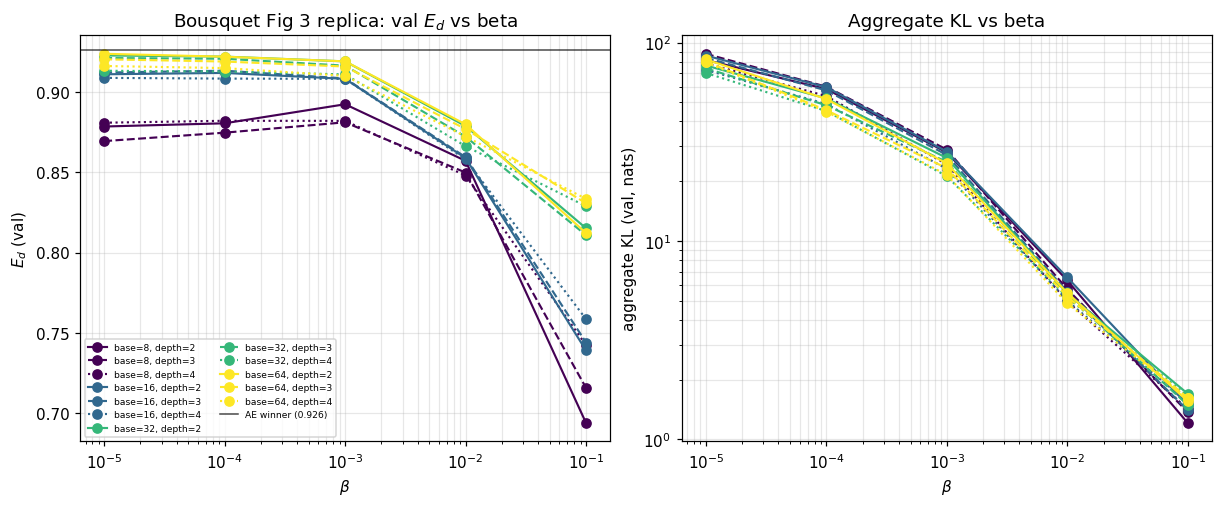

In [7]:
# Bousquet Fig 3 replica: E_d (val) vs beta (left), aggregate KL vs beta
# (right), one line per (base, depth). Colour by base, linestyle by depth.
BASE_COLORS = {b: plt.get_cmap("viridis")(i / max(len(BASE_CHANNELS) - 1, 1))
               for i, b in enumerate(BASE_CHANNELS)}
DEPTH_STYLES = {2: "-", 3: "--", 4: ":"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax = axes[0]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["val_E_d"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="o", lw=1.4,
            label=f"base={base}, depth={depth}",
        )
ax.axhline(AE_VAL_E_D, color="k", lw=1.0, alpha=0.7, label=f"AE winner ({AE_VAL_E_D:.3f})")
ax.set_xscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$E_d$ (val)")
ax.set_title("Bousquet Fig 3 replica: val $E_d$ vs beta")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=6, ncol=2, loc="lower left")

ax = axes[1]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["val_kl_total"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="o", lw=1.4,
        )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"aggregate KL (val, nats)")
ax.set_title("Aggregate KL vs beta")
ax.grid(True, alpha=0.3, which="both")

fig.savefig(FIG_DIR / "stage1_bousquet_fig3.png", bbox_inches="tight", dpi=120)
plt.show()


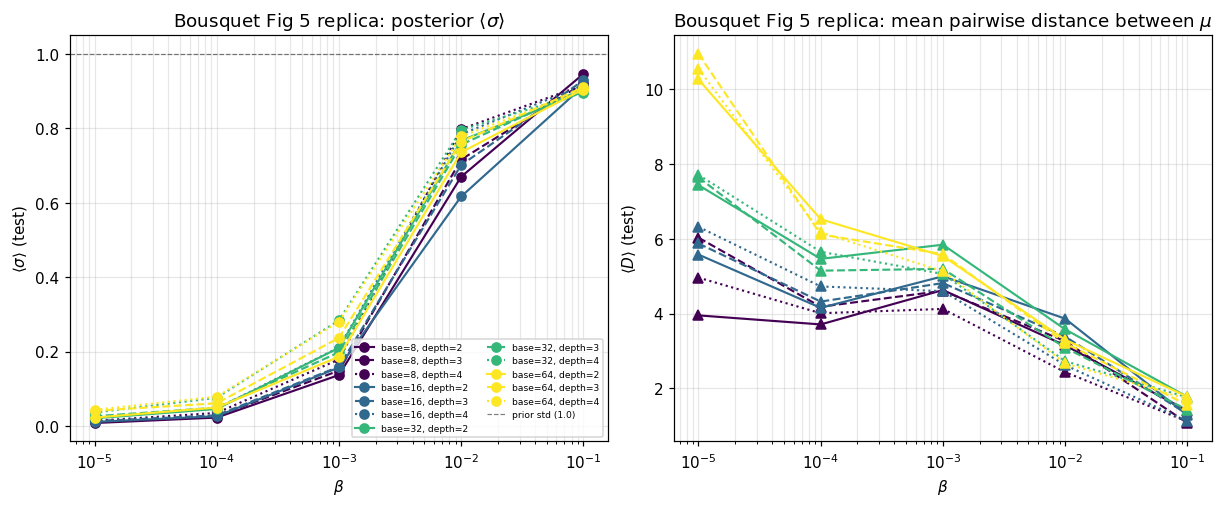

In [8]:
# Bousquet Fig 5 replica: <sigma> = mean of exp(0.5 * logvar) on test;
# <D> = mean pairwise L2 distance between mu vectors on test. Same
# colour/style scheme as Fig 3.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax = axes[0]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_aux_df[(stage1_aux_df["base_channels"] == base) & (stage1_aux_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["test_sigma_mean"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="o", lw=1.4,
            label=f"base={base}, depth={depth}",
        )
ax.axhline(1.0, color="k", lw=0.8, alpha=0.5, ls="--", label="prior std (1.0)")
ax.set_xscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\langle\sigma\rangle$ (test)")
ax.set_title("Bousquet Fig 5 replica: posterior $\\langle\\sigma\\rangle$")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=6, ncol=2, loc="lower right")

ax = axes[1]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_aux_df[(stage1_aux_df["base_channels"] == base) & (stage1_aux_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["test_pair_dist_mean"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="^", lw=1.4,
        )
ax.set_xscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\langle D\rangle$ (test)")
ax.set_title("Bousquet Fig 5 replica: mean pairwise distance between $\\mu$")
ax.grid(True, alpha=0.3, which="both")

fig.savefig(FIG_DIR / "stage1_bousquet_fig5.png", bbox_inches="tight", dpi=120)
plt.show()


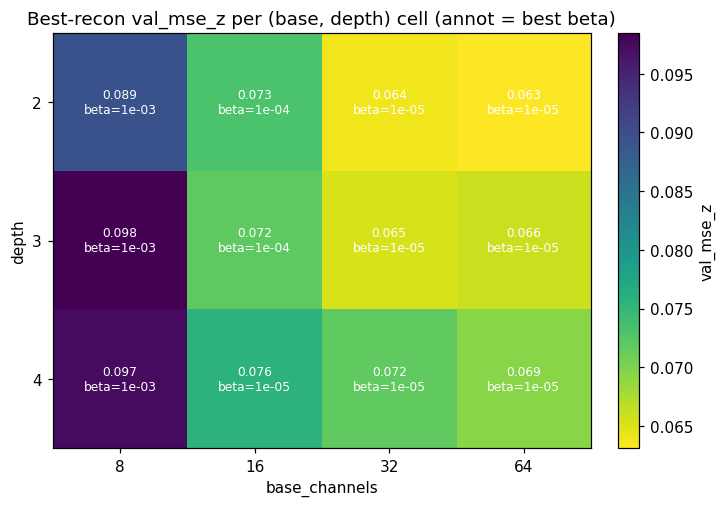

In [9]:
# Stage-1 (base, depth) overview: for each (base, depth) cell, the
# best-recon beta and its val_mse_z. Exploratory only; not a selection.
overview_rows = []
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        best = sub.sort_values("val_mse_z").iloc[0]
        overview_rows.append({
            "base_channels": base,
            "depth":         depth,
            "best_beta":     float(best["beta"]),
            "val_mse_z":     float(best["val_mse_z"]),
        })
overview_df = pd.DataFrame(overview_rows)

grid_mse = overview_df.pivot(index="depth", columns="base_channels", values="val_mse_z")
grid_beta = overview_df.pivot(index="depth", columns="base_channels", values="best_beta")

fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
im = ax.imshow(grid_mse.values, aspect="auto", cmap="viridis_r")
ax.set_xticks(range(len(grid_mse.columns)), [f"{b}" for b in grid_mse.columns])
ax.set_yticks(range(len(grid_mse.index)), [f"{d}" for d in grid_mse.index])
ax.set_xlabel("base_channels")
ax.set_ylabel("depth")
ax.set_title("Best-recon val_mse_z per (base, depth) cell (annot = best beta)")
for i in range(grid_mse.shape[0]):
    for j in range(grid_mse.shape[1]):
        ax.text(
            j, i, f"{grid_mse.values[i, j]:.3f}\nbeta={grid_beta.values[i, j]:.0e}",
            ha="center", va="center", color="w", fontsize=8,
        )
fig.colorbar(im, ax=ax, label="val_mse_z")
fig.savefig(FIG_DIR / "stage1_heatmap.png", bbox_inches="tight", dpi=120)
plt.show()


### Per-dim KL collapse diagnostic

Heatmap of `KL_k` across all 60 Stage-1 configs and all 16 latent dims.
Rows are sorted by `beta` first (5 horizontal bands), then by
`(base, depth)` within each band. The colormap diverges around the alive
threshold `DIM_ALIVE_KL` (=1.0 nat by default): red cells are collapsed
or near-collapsed dims, green cells are active dims. Use this to spot
configs whose aggregate KL is small only because individual dims have
gone dead.


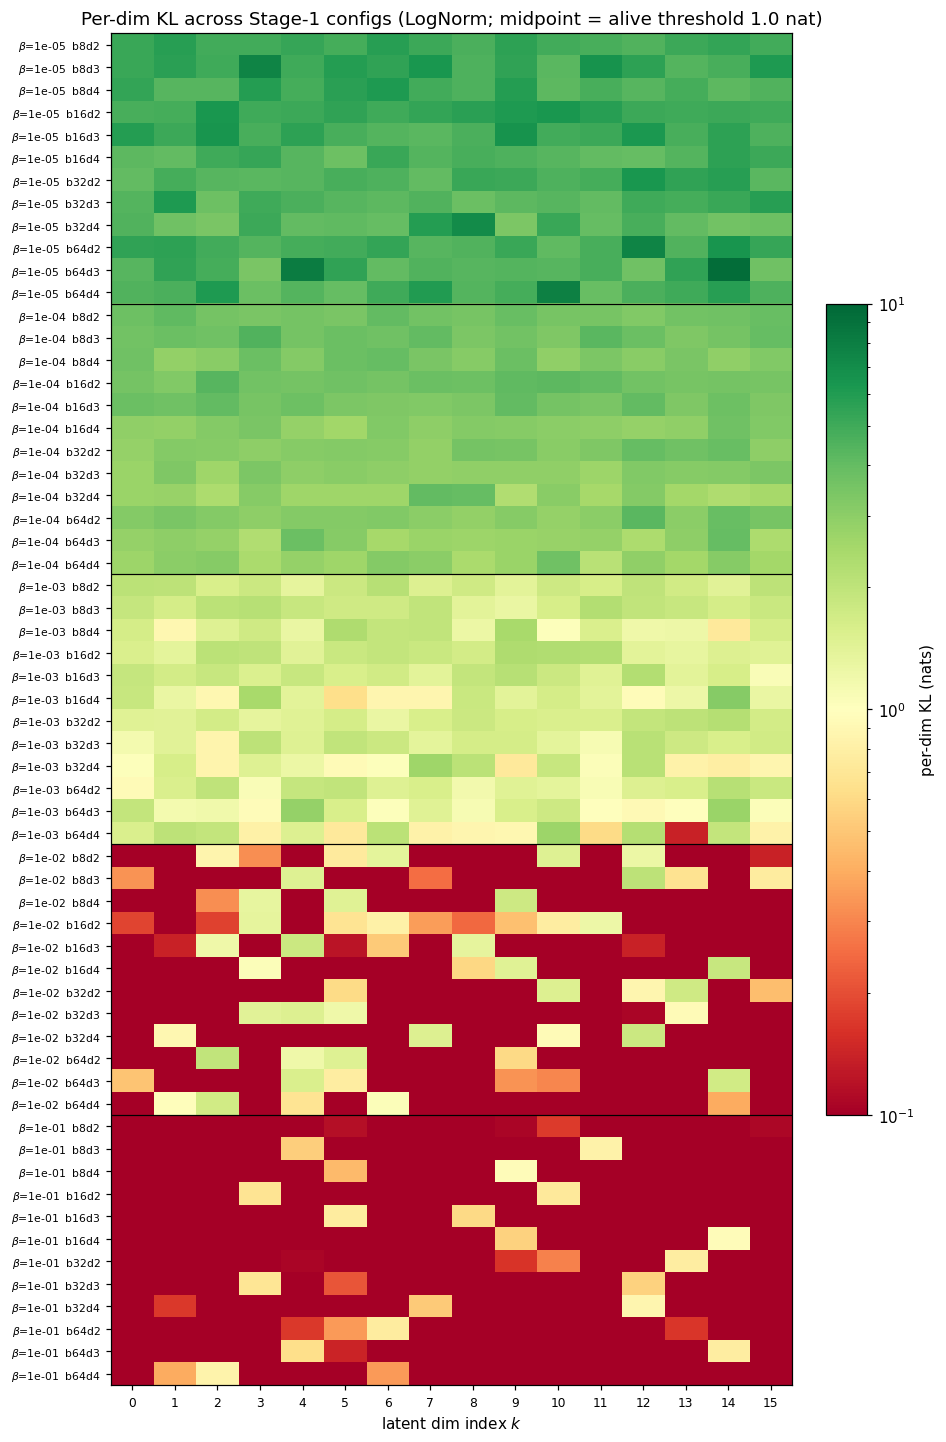

In [10]:
from matplotlib.colors import LogNorm

# Sort by beta then (base, depth) so the heatmap has 5 horizontal bands
# (one per beta), each showing the 12 architectures.
sorted_rows = stage1_df.sort_values(
    ["beta", "base_channels", "depth"]
).reset_index(drop=True)
kl_cols = [f"val_kl_dim_{j}" for j in range(LATENT_DIM)]
kl_matrix = sorted_rows[kl_cols].values  # (60, LATENT_DIM)

# LogNorm centred on the alive threshold: log10(0.1) and log10(10) are
# symmetric around log10(1.0), so the colormap midpoint lands at the
# threshold value DIM_ALIVE_KL.
vmin = max(1e-4, DIM_ALIVE_KL * 0.1)
vmax = DIM_ALIVE_KL * 10
clipped = np.clip(kl_matrix, vmin, vmax)

fig, ax = plt.subplots(figsize=(8.5, 13), constrained_layout=True)
im = ax.imshow(
    clipped, aspect="auto", cmap="RdYlGn",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    interpolation="nearest",
)
ax.set_xticks(range(LATENT_DIM))
ax.set_xticklabels([str(j) for j in range(LATENT_DIM)], fontsize=8)
ax.set_xlabel("latent dim index $k$")

row_labels = [
    f"$\\beta$={r.beta:.0e}  b{r.base_channels}d{r.depth}"
    for r in sorted_rows.itertuples()
]
ax.set_yticks(range(len(sorted_rows)))
ax.set_yticklabels(row_labels, fontsize=7)

# Horizontal separators between beta bands so the structure is obvious.
prev_beta = None
for i, row in enumerate(sorted_rows.itertuples()):
    if prev_beta is not None and row.beta != prev_beta:
        ax.axhline(i - 0.5, color="black", lw=0.8)
    prev_beta = row.beta

ax.set_title(
    f"Per-dim KL across Stage-1 configs (LogNorm; midpoint = "
    f"alive threshold {DIM_ALIVE_KL:.1f} nat)"
)
fig.colorbar(im, ax=ax, label="per-dim KL (nats)", shrink=0.6)
fig.savefig(FIG_DIR / "stage1_per_dim_kl.png", bbox_inches="tight", dpi=120)
plt.show()


## Stage 1 candidate inspection

Three sorts so the manual choice is easy to compare. `n_active_dims`
counts dims with `KL_k > DIM_ALIVE_KL`. The third sort restricts to
configs whose latent is healthy (`n_active_dims >= MIN_ACTIVE_DIMS`),
then ranks by recon; this is usually the most useful view for picking a
balanced winner.


In [11]:
# Threshold for "healthy latent" in the third inspection view. Out of
# LATENT_DIM=16 dims, a config with at least MIN_ACTIVE_DIMS dims above
# the alive threshold is considered structurally healthy.
MIN_ACTIVE_DIMS = 14

kl_cols = [f"val_kl_dim_{j}" for j in range(LATENT_DIM)]
df = stage1_df.copy()
df["n_active_dims"] = (df[kl_cols] > DIM_ALIVE_KL).sum(axis=1)

display_cols = [
    "base_channels", "depth", "beta",
    "val_mse_z", "val_E_d", "val_kl_total",
    "val_kl_per_dim_min", "n_active_dims",
    "val_mu_norm", "val_post_cov_diag_mean",
    "n_params", "epochs_trained",
]

print("=" * 80)
print("Top 10 by recon (smallest val_mse_z, ignores collapse):")
print("=" * 80)
print(df.sort_values("val_mse_z").head(10)[display_cols].to_string(index=False))

print("\n" + "=" * 80)
print("Top 10 by aggregate KL (smallest val_kl_total, ignores recon):")
print("=" * 80)
print(df.sort_values("val_kl_total").head(10)[display_cols].to_string(index=False))

print("\n" + "=" * 80)
print(
    f"Top 10 healthy configs (n_active_dims >= {MIN_ACTIVE_DIMS}), "
    f"ranked by val_mse_z:"
)
print("=" * 80)
healthy = df[df["n_active_dims"] >= MIN_ACTIVE_DIMS]
if healthy.empty:
    print(
        f"(no configs meet n_active_dims >= {MIN_ACTIVE_DIMS}; "
        f"lower MIN_ACTIVE_DIMS to inspect)"
    )
else:
    print(healthy.sort_values("val_mse_z").head(10)[display_cols].to_string(index=False))


Top 10 by recon (smallest val_mse_z, ignores collapse):
 base_channels  depth    beta  val_mse_z  val_E_d  val_kl_total  val_kl_per_dim_min  n_active_dims  val_mu_norm  val_post_cov_diag_mean  n_params  epochs_trained
            64      2 0.00001   0.063133 0.923784     82.188530            4.095953             16     5.440645                1.840019    971906             155
            32      2 0.00001   0.063874 0.922752     76.615372            3.995625             16     3.954705                0.882917    444498             273
            32      2 0.00010   0.064495 0.922026     52.263779            2.808150             16     2.736789                0.550756    444498             245
            64      2 0.00010   0.064559 0.921980     51.910774            2.795988             16     3.343854                0.840441    971906             123
            32      3 0.00001   0.065311 0.921147     74.152039            3.762845             16     4.282314                1.55927

## Optional Stage 2: lr x weight_decay sweep at a user-chosen target

Gated on `STAGE2_TARGET` in the constants cell. Set it to a
`(base, depth, beta)` triple to refine the optimiser hypers at that
config; leave as `None` to skip. Stage 1 uses fixed `LR_STAGE1` and
`WD_STAGE1`, so Stage 2 is the place to confirm those defaults or
adjust them.


In [19]:
STAGE2_TARGET: tuple[int, int, float] | None = (64, 4, 1e-1)

In [20]:
if STAGE2_TARGET is None:
    print(
        "Stage 2 skipped. Set STAGE2_TARGET = (base, depth, beta) in the "
        "constants cell and re-run from this cell to refine optimiser hypers."
    )
else:
    BASE_S2, DEPTH_S2, BETA_S2 = STAGE2_TARGET
    print(f"Stage 2 target: base={BASE_S2}, depth={DEPTH_S2}, beta={BETA_S2:.0e}")

    stage2_rows: list[dict] = []
    stage2_configs = [(lr, wd) for lr in LRS for wd in WDS]

    for i, (lr, wd) in enumerate(stage2_configs, start=1):
        print(f"\n[Stage 2 {i}/{len(stage2_configs)}] lr={lr:.0e}  wd={wd:.0e}")
        result = train_one_config_vae(
            base_channels=BASE_S2, depth=DEPTH_S2, beta=BETA_S2,
            lr=lr, weight_decay=wd,
        )
        m = result["val_metrics"]
        diag = result["val_diag"]
        row = {
            "lr":                     lr,
            "weight_decay":           wd,
            "val_mse_z":              m["mse_z"],
            "val_rmse_z":             m["rmse_z"],
            "val_rrmse":              m["rrmse"],
            "val_r_squared":          m["r_squared"],
            "val_E_d":                m["E_d"],
            "val_kl_total":           diag["kl_total"],
            "val_kl_per_dim_max":     float(diag["kl_per_dim"].max()),
            "val_kl_per_dim_min":     float(diag["kl_per_dim"].min()),
            "val_total_loss":         result["val_total_loss"],
            "val_mu_norm":            diag["mu_norm"],
            "val_post_cov_diag_mean": diag["post_cov_diag_mean"],
            "n_params":               result["n_params"],
            "epochs_trained":         result["epochs_trained"],
            "best_epoch":             result["best_epoch"],
        }
        for j, kl_j in enumerate(diag["kl_per_dim"]):
            row[f"val_kl_dim_{j}"] = float(kl_j)
        stage2_rows.append(row)
        pd.DataFrame(stage2_rows).to_csv(STAGE2_CSV, index=False)

        print(
            f"  val_mse_z={m['mse_z']:.4f}  E_d={m['E_d']:.3f}  "
            f"KL_total={diag['kl_total']:.3f}  "
            f"epochs={result['epochs_trained']}  ({result['seconds']:.0f}s)"
        )

    stage2_df = pd.read_csv(STAGE2_CSV)
    print(f"\nStage 2 complete: {len(stage2_df)} rows written to {STAGE2_CSV.relative_to(OUT_DIR.parent)}")


Stage 2 target: base=64, depth=4, beta=1e-01

[Stage 2 1/9] lr=3e-04  wd=1e-05


train_vae(d=16,beta=1e-01):  17%|█▋        | 84/500 [00:11<00:58,  7.08ep/s, val_total=0.3382, best=0.3016, beta=1e-01, s/ep=0.1]


  val_mse_z=0.1405  E_d=0.833  KL_total=1.611  epochs=85  (12s)

[Stage 2 2/9] lr=3e-04  wd=1e-04


train_vae(d=16,beta=1e-01):  17%|█▋        | 84/500 [00:11<00:57,  7.25ep/s, val_total=0.3382, best=0.3016, beta=1e-01, s/ep=0.1]


  val_mse_z=0.1405  E_d=0.833  KL_total=1.611  epochs=85  (12s)

[Stage 2 3/9] lr=3e-04  wd=1e-03


...

  val_mse_z=0.1503  E_d=0.821  KL_total=1.788  epochs=96  (13s)

[Stage 2 8/9] lr=3e-03  wd=1e-04


train_vae(d=16,beta=1e-01):  23%|██▎       | 113/500 [00:15<00:54,  7.15ep/s, val_total=0.3556, best=0.3134, beta=1e-01, s/ep=0.1]


  val_mse_z=0.1519  E_d=0.818  KL_total=1.614  epochs=114  (16s)

[Stage 2 9/9] lr=3e-03  wd=1e-03


train_vae(d=16,beta=1e-01):  12%|█▏        | 62/500 [00:08<01:03,  6.94ep/s, val_total=0.3531, best=0.3311, beta=1e-01, s/ep=0.1]

  val_mse_z=0.1763  E_d=0.791  KL_total=1.548  epochs=63  (9s)

Stage 2 complete: 9 rows written to outputs/csvs/05_vae_sweep/stage2.csv


## Stage 2 figure


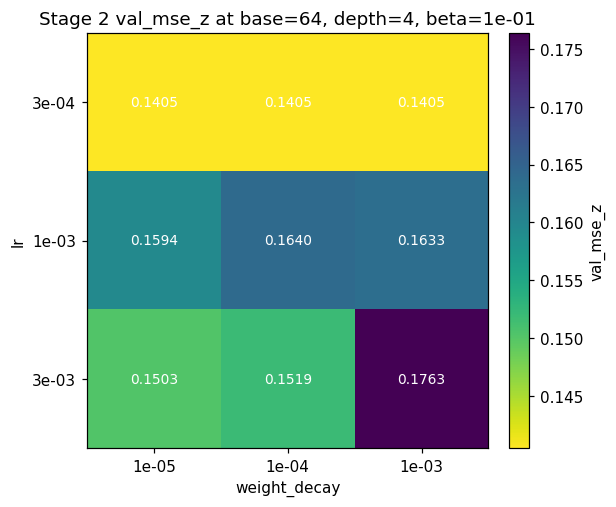

In [21]:
if STAGE2_TARGET is None:
    print("Stage 2 figure skipped (Stage 2 not run).")
else:
    grid = stage2_df.pivot(index="lr", columns="weight_decay", values="val_mse_z")
    fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
    im = ax.imshow(grid.values, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(grid.columns)), [f"{w:.0e}" for w in grid.columns])
    ax.set_yticks(range(len(grid.index)),   [f"{l:.0e}" for l in grid.index])
    ax.set_xlabel("weight_decay")
    ax.set_ylabel("lr")
    ax.set_title(
        f"Stage 2 val_mse_z at base={BASE_S2}, depth={DEPTH_S2}, beta={BETA_S2:.0e}"
    )
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid.values[i, j]:.4f}", ha="center", va="center",
                    color="w", fontsize=9)
    fig.colorbar(im, ax=ax, label="val_mse_z")
    fig.savefig(FIG_DIR / "stage2_lr_wd_grid.png", bbox_inches="tight", dpi=120)
    plt.show()


## Stage 2 candidate inspection


In [22]:
if STAGE2_TARGET is None:
    print("Stage 2 inspection skipped (Stage 2 not run).")
else:
    stage2_sorted = stage2_df.sort_values("val_mse_z").reset_index(drop=True)
    print("Stage 2 sorted by val_mse_z:")
    print(stage2_sorted[[
        "lr", "weight_decay",
        "val_mse_z", "val_E_d", "val_kl_total",
        "val_kl_per_dim_min", "epochs_trained",
    ]].to_string(index=False))


Stage 2 sorted by val_mse_z:
    lr  weight_decay  val_mse_z  val_E_d  val_kl_total  val_kl_per_dim_min  epochs_trained
0.0003       0.00010   0.140511 0.833474      1.610987            0.000179              85
0.0003       0.00001   0.140516 0.833469      1.611069            0.000180              85
0.0003       0.00100   0.140528 0.833456      1.611071            0.000181              85
0.0030       0.00001   0.150275 0.821330      1.787662            0.000269              96
0.0030       0.00010   0.151938 0.818369      1.614220            0.000317             114
0.0010       0.00001   0.159448 0.811468      1.599611            0.000146             101
0.0010       0.00100   0.163330 0.806026      1.725034            0.000407              61
0.0010       0.00010   0.163963 0.805302      1.721179            0.000418              61
0.0030       0.00100   0.176347 0.790722      1.548020            0.001579              63


## Transfer to notebook 06

Pick a config from the inspection tables above, then open
`06_vae_sweep_winner.ipynb` and edit the architecture-config block:

```python
BASE_STAR = <your choice>
DEPTH_STAR = <your choice>
BETA_STAR = <your choice>
LR_STAR = <Stage 2 winner if you ran it, else 3e-4>
WD_STAR = <Stage 2 winner if you ran it, else 1e-4>
```

Notebook 06 is file-independent: it reads no checkpoints, only these
constants.

The summary table below repeats the three top-N inspection sorts as a
single recap so the copy-to-06 step is one glance away.


In [23]:
TOP_N = 5

summary_cols = [
    "base_channels", "depth", "beta",
    "val_mse_z", "val_E_d", "val_kl_total",
    "n_active_dims",
]

print("=" * 70)
print(f"SUMMARY: top {TOP_N} per sort (Stage 1)")
print("=" * 70)

print(f"\n[A] Smallest val_mse_z (best recon, ignores collapse):")
print(df.sort_values("val_mse_z").head(TOP_N)[summary_cols].to_string(index=False))

print(f"\n[B] Smallest val_kl_total (closest aggregate to N(0, I)):")
print(df.sort_values("val_kl_total").head(TOP_N)[summary_cols].to_string(index=False))

print(
    f"\n[C] Healthy configs only (n_active_dims >= {MIN_ACTIVE_DIMS}), "
    f"sorted by val_mse_z:"
)
healthy = df[df["n_active_dims"] >= MIN_ACTIVE_DIMS]
if healthy.empty:
    print(f"(none meet n_active_dims >= {MIN_ACTIVE_DIMS}; lower the threshold)")
else:
    print(healthy.sort_values("val_mse_z").head(TOP_N)[summary_cols].to_string(index=False))

if STAGE2_TARGET is not None:
    print("\n" + "=" * 70)
    print("Stage 2 best lr/wd at the chosen target:")
    print("=" * 70)
    print(
        stage2_df.sort_values("val_mse_z").head(TOP_N)[[
            "lr", "weight_decay",
            "val_mse_z", "val_E_d", "val_kl_total",
        ]].to_string(index=False)
    )


SUMMARY: top 5 per sort (Stage 1)

[A] Smallest val_mse_z (best recon, ignores collapse):
 base_channels  depth    beta  val_mse_z  val_E_d  val_kl_total  n_active_dims
            64      2 0.00001   0.063133 0.923784     82.188530             16
            32      2 0.00001   0.063874 0.922752     76.615372             16
            32      2 0.00010   0.064495 0.922026     52.263779             16
            64      2 0.00010   0.064559 0.921980     51.910774             16
            32      3 0.00001   0.065311 0.921147     74.152039             16

[B] Smallest val_kl_total (closest aggregate to N(0, I)):
 base_channels  depth  beta  val_mse_z  val_E_d  val_kl_total  n_active_dims
             8      2   0.1   0.254713 0.693958      1.208385              0
             8      3   0.1   0.238420 0.715795      1.371846              0
            16      3   0.1   0.214546 0.744070      1.402665              0
             8      4   0.1   0.215995 0.742461      1.422176        